# COSI Pulsar Analysis Tutorial: Phase Assignment and Filtering

## Overview
This tutorial demonstrates a complete workflow for performing phase-resolved pulsar analysis using `cosipy` and custom time-domain tools. Using Data Challenge 2 (DC2) FITS data for the Crab pulsar and its accompanying albedo background, this notebook guides you through the process of preparing unbinned photon events, assigning rotational phases, and extracting specific pulse intervals.

## Objectives
By the end of this notebook, you will learn how to:
* **Combine and Time-Slice Data:** Merge unbinned source and background datasets, and filter them down to specific Mission Elapsed Time (MET) windows for faster processing.
* **Assign Pulsar Phases:** Use a pulsar ephemeris parameter file (`.par`) to calculate and append the precise rotational phase (0.0 to 1.0) to individual photon events.
* **Visualize the Pulse Profile:** Generate a folded light curve (pulse profile) to visually inspect the on-pulse peaks and off-pulse baseline.
* **Perform Phase Selection:** Filter the phase-assigned data to isolate specific windows, such as the `on-pulse` and `off-pulse` regions, outputting the results into new FITS files for downstream spatial or spectral analysis.

## Prerequisites
To run this notebook, ensure you have the following in your working directory:
* A valid ephemeris file (e.g., `crab.par`)


* **`from cosipy import BinnedData`**: Imports the `BinnedData` class from the `cosipy` library, which is used for handling and analyzing binned datasets.
* **`from cosipy.data_io import UnBinnedData`**: Imports the `UnBinnedData` class to handle raw, unbinned photon event data.
* **`from astropy.io import fits`**: Imports the `fits` module from the Astropy package to read, manipulate, and write FITS (Flexible Image Transport System) files.
* **`from time_selector import TimeSelector`**: Imports a custom script/class to filter datasets based on specific time windows.
* **`from phase_selector import PhaseSelector`**: Imports a custom script/class to filter pulsar data based on specific phase intervals.
* **`from plot_pulse_profile import PlotPulseProfile`**: Imports a custom class designed to generate and visualize pulsar light curves (pulse profiles).
* **`%matplotlib inline`**: A Jupyter Notebook magic command that ensures any generated plots are displayed directly below the code cell within the notebook.

In [1]:
from cosipy import BinnedData
from cosipy.data_io import UnBinnedData
from astropy.io import fits

from time_selector import TimeSelector
from phase_selector import PhaseSelector
from plot_pulse_profile import PlotPulseProfile

%matplotlib inline

03:32:41 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=468866;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=319189;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=929869;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=818925;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=363830;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=944819;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

03:32:42 INFO      Starting 3ML!                                                                     ]8;id=145512;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=316652;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#39\39]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=294252;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=443010;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#40\40]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=863462;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=366769;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=620919;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=982860;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=127554;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=248758;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=932273;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=706884;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=370463;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=322125;file:///home/abhi/anaconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

* **`# fetch_wasabi_file(...)`**: They use a custom function to download the unbinned Crab source data and Albedo background data FITS files from a remote Wasabi cloud storage bucket to a local directory.

In [ ]:
fetch_wasabi_file('COSI-SMEX/DC2/Data/Sources/Crab_DC2_3months_unbinned_data.fits.gz', output=str('Crab_DC2_3months_unbinned_data.fits.gz'))

In [ ]:
fetch_wasabi_file('COSI-SMEX/DC2/Data/Backgrounds/albedo_photons_3months_unbinned_data.fits.gz', output=str("albedo_photons_3months_unbinned_data.fits.gz"))

In [ ]:
fetch_wasabi_file('COSI-SMEX/DC2/Data/Orientation/20280301_3_month_with_orbital_info.ori', output=str('20280301_3_month_with_orbital_info.ori'))

* **`analysis.combine_unbinned_data(...)`**: It shows how to use the `cosipy` analysis object to merge the unbinned Crab data and Albedo background data into a single FITS file named "crab_with_albedo_background".

In [ ]:
analysis.combine_unbinned_data(["Crab_DC2_3months_unbinned_data.fits.gz","albedo_photons_3months_unbinned_data.fits.gz"], output_name="crab_with_albedo_background")

* **`met_start = 1835478000.0`**: Defines the starting timestamp for the data slice using Mission Elapsed Time (MET) in seconds.
* **`met_stop = met_start + 86400.0`**: Calculates the stopping timestamp by adding 1 days (where 1 day = 86,400 seconds) to the start time.
* **`for f_in, f_out in [...]`**: Initiates a loop to process two pairs of files: the Crab data and the Albedo background data, assigning input and output filenames.
* **`with fits.open(f_in) as hdul:`**: Safely opens the input FITS file as an HDUList (Header Data Unit List) ensuring it closes automatically when done.
* **`data = hdul[1].data`**: Extracts the actual event data table, which is typically stored in the first extension (index 1) of the FITS file.
* **`mask = (data['TimeTags'] >= met_start) & (data['TimeTags'] <= met_stop)`**: Creates a boolean array (mask) that is `True` only for rows where the 'TimeTags' column falls within the defined 10-day MET window.
* **`new_hdu = fits.BinTableHDU(data[mask], header=hdul[1].header)`**: Creates a new FITS binary table containing only the filtered data while copying over the original header metadata.
* **`fits.HDUList([hdul[0], new_hdu]).writeto(f_out, overwrite=True)`**: Packages the original primary header (`hdul[0]`) and the newly filtered table into a new FITS file and saves it to disk, overwriting any existing file with the same name.
* **`print(...)`**: Outputs a status message to the console showing the name of the created file and the number of events it contains.

In [ ]:
met_start = 1835478000.0
met_stop = met_start + 86400.0

for f_in, f_out in [("Crab_DC2_3months_unbinned_data.fits", "crab_1d.fits"), 
                    ("albedo_photons_3months_unbinned_data.fits", "albedo_1d.fits")]:
    with fits.open(f_in) as hdul:
        data = hdul[1].data
        mask = (data['TimeTags'] >= met_start) & (data['TimeTags'] <= met_stop)
        
        new_hdu = fits.BinTableHDU(data[mask], header=hdul[1].header)
        fits.HDUList([hdul[0], new_hdu]).writeto(f_out, overwrite=True)
    print(f"Slice created: {f_out} ({mask.sum()} events)")


Slice created: crab_1d.fits (831909 events)
Slice created: albedo_1d.fits (5241280 events)


* **`analysis = BinnedData("inputs.yaml")`**: Initializes a COSI analysis object, loading the necessary configuration parameters from the "inputs.yaml" file.
* **`analysis.combine_unbinned_data(["crab_1d.fits", "albedo_1d.fits"], output_name="crab_with_albedo_1d")`**: Takes the two locally sliced FITS files (Crab and Albedo) and merges them into a single comprehensive dataset named "crab_with_albedo_1d".

In [ ]:
analysis = BinnedData("inputs.yaml")
analysis.combine_unbinned_data(["crab_1d.fits", "albedo_1d.fits"], output_name="crab_with_albedo_1d")


adding crab_1d.fits...


adding albedo_1d.fits...



* **`import phase_assigner as pa`**: Imports the custom module responsible for calculating pulsar phases.
* **`ephemeris_file = "crab.par"`**: Sets the filepath to the ephemeris parameter file, which contains the precise timing information (like frequency and derivatives) for the Crab pulsar.
* **`input_fits_file = ...`**: Defines the target FITS file that needs pulsar phases assigned.
* **`output_fits_file = ...`**: Defines the name of the new FITS file that will contain the original data plus the new phase column.
* **`assigner = pa.PhaseAssigner(ephemeris_file)`**: Initializes the phase assigner object, passing in the ephemeris data so it knows the pulsar's timing model.
* **`print(f"Pulsar Frequency: {assigner.f0:.6f} Hz")`**: Prints the base spin frequency of the pulsar extracted from the `.par` file for verification.
* **`assigner.add_phase_column(input_fits_file, output_fits_file)`**: Reads the input FITS file, calculates the exact rotational phase (0.0 to 1.0) for every photon based on its arrival time, adds this as a new 'PULSE_PHASE' column, and writes the result to the output file.
* **`print(...)`**: Prints a success message confirming the new file was created.

In [ ]:
import phase_assigner as pa

ephemeris_file = "crab.par"
input_fits_file = "crab_with_albedo_1d.fits"
output_fits_file = "crab_with_albedo_1d_with_pulse_phase_column.fits"

assigner = pa.PhaseAssigner(ephemeris_file)
print(f"Pulsar Frequency: {assigner.f0:.6f} Hz")

assigner.add_phase_column(input_fits_file, output_fits_file)

print(f"Done! Created: {output_fits_file}")

INFO:phase_assigner:Creating PULSE_PHASE column.


Pulsar Frequency: 29.946923 Hz


INFO:phase_assigner:Saved: crab_with_albedo_1d_with_pulse_phase_column.fits


Done! Created: crab_with_albedo_1d_with_pulse_phase_column.fits


In [ ]:
ephemeris_file = "crab.par"
input_fits_file = "albedo_1d.fits"
output_fits_file = "albedo_1d_with_pulse_phase_column.fits"

assigner = pa.PhaseAssigner(ephemeris_file)
print(f"Pulsar Frequency: {assigner.f0:.6f} Hz")

assigner.add_phase_column(input_fits_file, output_fits_file)

print(f"Done! Created: {output_fits_file}")

Pulsar Frequency: 29.946923 Hz


INFO:phase_assigner:Creating PULSE_PHASE column.
INFO:phase_assigner:Saved: albedo_1d_with_pulse_phase_column.fits


Done! Created: albedo_1d_with_pulse_phase_column.fits


In [ ]:
ephemeris_file = "crab.par"
input_fits_file = "crab_1d.fits"
output_fits_file = "crab_1d_with_pulse_phase_column.fits"

assigner = pa.PhaseAssigner(ephemeris_file)
print(f"Pulsar Frequency: {assigner.f0:.6f} Hz")

assigner.add_phase_column(input_fits_file, output_fits_file)

print(f"Done! Created: {output_fits_file}")

INFO:phase_assigner:Creating PULSE_PHASE column.


Pulsar Frequency: 29.946923 Hz


INFO:phase_assigner:Saved: crab_1d_with_pulse_phase_column.fits


Done! Created: crab_1d_with_pulse_phase_column.fits


* **`filename = "crab_with_albedo_1d_with_pulse_phase_column.fits"`**: Sets the variable to the combined data file that now includes the calculated pulse phases.
* **`with fits.open(filename) as hdul:`**: Safely opens the FITS file.
* **`pp = PlotPulseProfile(hdul[1].data)`**: Initializes the custom plotting class, feeding it the raw event table containing the phases.
* **`pp.plot()`**: Triggers the function to generate and display the folded light curve (pulse profile) plot.

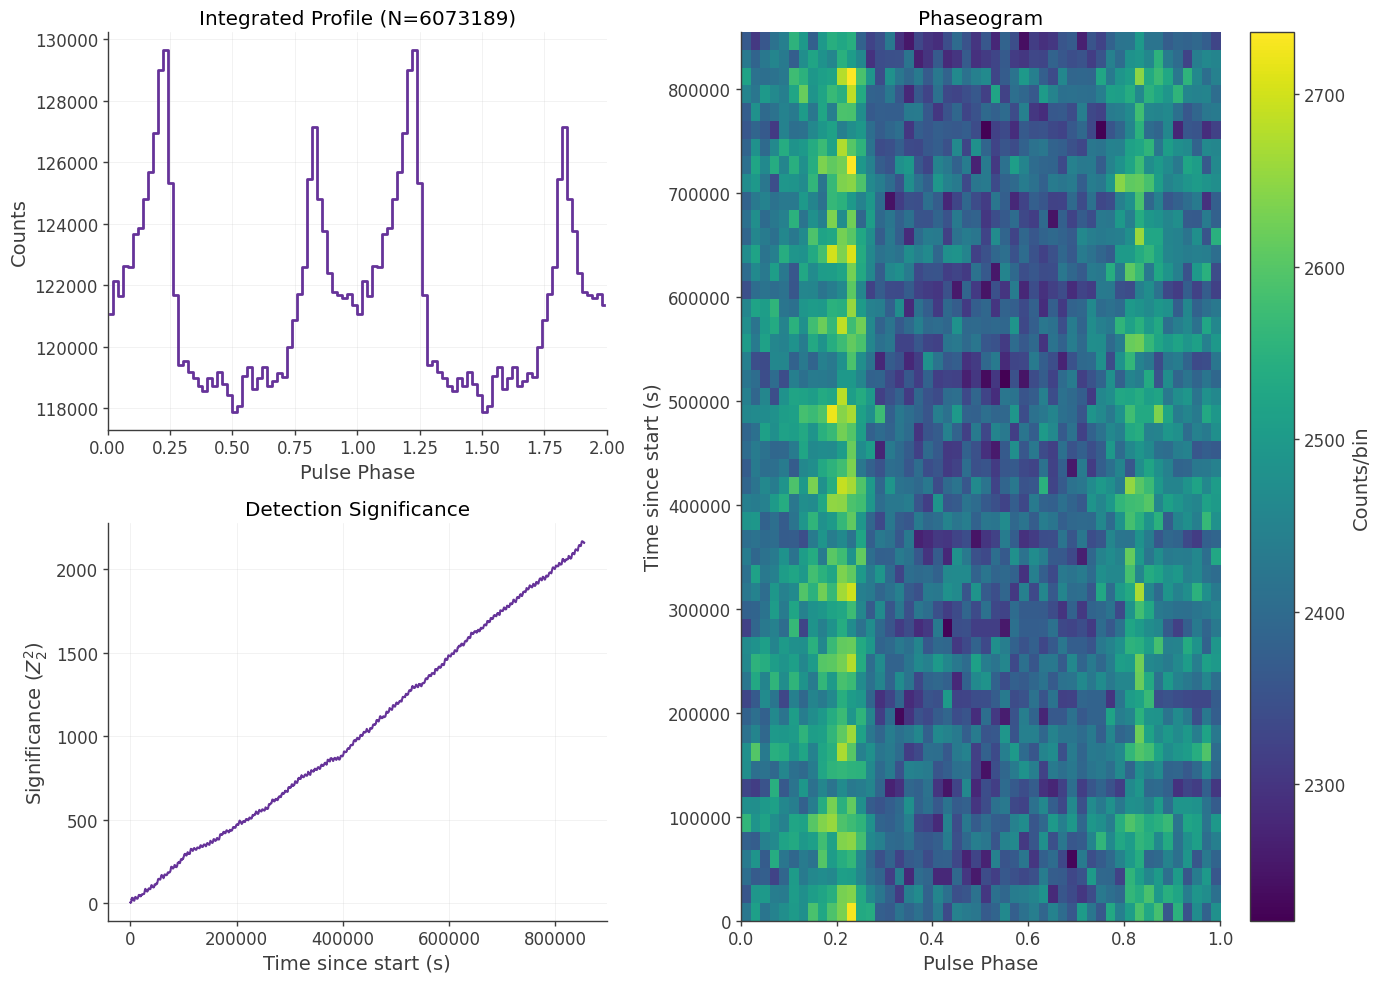

In [ ]:
filename = "crab_with_albedo_1d_with_pulse_phase_column.fits"
with fits.open(filename) as hdul:
    pp = PlotPulseProfile(hdul[1].data)
    pp.plot()

* **`pstart = ...`**: Defines the starting phase of the selection window (e.g., 0.70 for the start of the on-pulse).
* **`pstop = ...`**: Defines the stopping phase of the selection window (e.g., 1.30, which the class will internally wrap/normalize to 0.30).
* **`ephemeris = "crab.par"`**: Specifies the parameter file to ensure the selector has the correct timing context.
* **`input_fits = ...`**: Specifies the FITS file containing the events and their assigned phases.
* **`phase_sel = PhaseSelector(ephemeris, pstart, pstop)`**: Initializes the selector object with the timing parameters and the desired phase window boundaries.
* **`on_pulse_events = phase_sel.filter_events(input_fits, output_fits=...)`**: Reads the input file, isolates only the photons whose 'PULSE_PHASE' falls within the specified `pstart` to `pstop` range, and saves this subset to the newly specified output FITS file.

In [ ]:
pstart = 0.70
pstop  = 1.30  # Will be normalized to 0.30
ephemeris = "crab.par"
input_fits = "crab_with_albedo_1d_with_pulse_phase_column.fits"

phase_sel = PhaseSelector(ephemeris, pstart, pstop)

on_pulse_events = phase_sel.filter_events(
    input_fits, 
    output_fits="crab_on_pulse_w_albedo.fits"
)

INFO:phase_selector:Auto-loading events from FITS: crab_with_albedo_1d_with_pulse_phase_column.fits
INFO:phase_selector:Saving 34442449 events to crab_on_pulse_w_albedo.fits...
INFO:phase_selector:Successfully saved: crab_on_pulse_w_albedo.fits


In [ ]:
pstart = 0.70
pstop  = 1.30  
ephemeris = "crab.par"
input_fits = "albedo_1d_with_pulse_phase_column.fits"

phase_sel = PhaseSelector(ephemeris, pstart, pstop)

on_pulse_events = phase_sel.filter_events(
    input_fits, 
    output_fits="on_pulse_only_albedo.fits"
)

INFO:phase_selector:Auto-loading events from FITS: albedo_1d_with_pulse_phase_column.fits
INFO:phase_selector:Saving 29300978 events to on_pulse_only_albedo.fits...
INFO:phase_selector:Successfully saved: on_pulse_only_albedo.fits


In [ ]:
pstart = 0.70
pstop  = 1.30  
ephemeris = "crab.par"
input_fits = "crab_1d_with_pulse_phase_column.fits"

phase_sel = PhaseSelector(ephemeris, pstart, pstop)

on_pulse_events = phase_sel.filter_events(
    input_fits, 
    output_fits="crab_1d_onpulse.fits"
)

INFO:phase_selector:Auto-loading events from FITS: crab_1d_with_pulse_phase_column.fits
INFO:phase_selector:Saving 5141471 events to crab_1d_onpulse.fits...
INFO:phase_selector:Successfully saved: crab_1d_onpulse.fits


In [ ]:
pstart = 0.30
pstop  = 0.70
ephemeris = "crab.par"
input_fits = "crab_with_albedo_1d_with_pulse_phase_column.fits" 

phase_sel = PhaseSelector(ephemeris, pstart, pstop)

on_pulse_events = phase_sel.filter_events(
    input_fits,
    output_fits="crab_off_pulse_w_albedo.fits")

INFO:phase_selector:Auto-loading events from FITS: crab_with_albedo_1d_with_pulse_phase_column.fits
INFO:phase_selector:Saving 22162772 events to crab_off_pulse_w_albedo.fits...
INFO:phase_selector:Successfully saved: crab_off_pulse_w_albedo.fits


## Conclusion

In this tutorial, we successfully processed raw, unbinned COSI data to assign rotational phases and extract specific phase intervals for the Crab pulsar and its corresponding albedo background. 

By isolating the `on-pulse` and `off-pulse` regions into separate FITS files, the data is now fully prepared for downstream scientific analysis. Specifically, these newly created files can be plugged directly into `cosipy` to perform a rigorous **Spectral Fit** for the Crab pulsar. This will allow you to characterize its high-energy emission spectrum and analyze the background-subtracted source components with precision.